In [15]:
import pandas as pd

data = pd.read_excel("../data/pakistan_aqi.xlsx")



In [16]:
pm25_data = data[data["Type"] == "PM 2.5"]

pm25_data.head()
pm25_data.shape

(1367, 4)

In [17]:
pm25_data.to_csv("../data/pakistan_pm25_clean.csv", index=False)

In [18]:
pm25_data.to_csv("../data/pakistan_pm25_clean.csv", index=False)

In [19]:
data.head()

,Date,City,Type,Count
0,2019-05-10,Lahore,PM 2.5,231
1,2019-05-11,Lahore,PM 2.5,171
2,2019-05-12,Lahore,PM 2.5,209
3,2019-05-13,Lahore,PM 2.5,188
4,2019-05-14,Lahore,PM 2.5,194


In [20]:
data.columns

Index(['Date', 'City', 'Type', 'Count'], dtype='object')

In [21]:
data["Type"].value_counts()


Type
PM 2.5    1367
Name: count, dtype: int64

In [22]:
pm25_data = data[data["Type"] == "PM 2.5"]

pm25_data.head()

,Date,City,Type,Count
0,2019-05-10,Lahore,PM 2.5,231
1,2019-05-11,Lahore,PM 2.5,171
2,2019-05-12,Lahore,PM 2.5,209
3,2019-05-13,Lahore,PM 2.5,188
4,2019-05-14,Lahore,PM 2.5,194


In [23]:
pm25_data.shape

(1367, 4)

In [24]:
pm25_data["City"].value_counts()

City
Islamabad    358
Lahore       347
Karachi      333
Peshawar     329
Name: count, dtype: int64

In [25]:
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])
pm25_data.dtypes

Date     datetime64[ns]
City             object
Type             object
Count            object
dtype: object

In [26]:
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])
pm25_data.dtypes


Date     datetime64[ns]
City             object
Type             object
Count            object
dtype: object

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

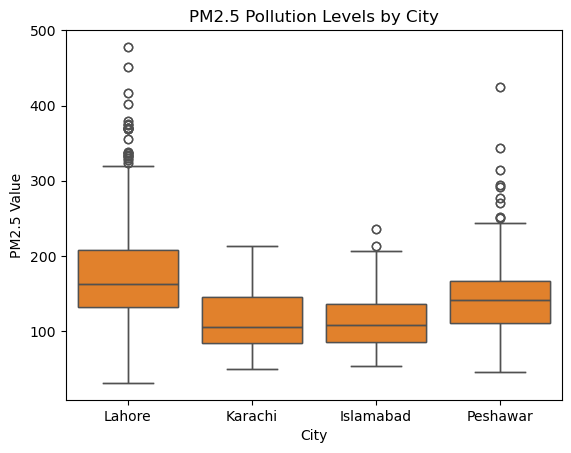

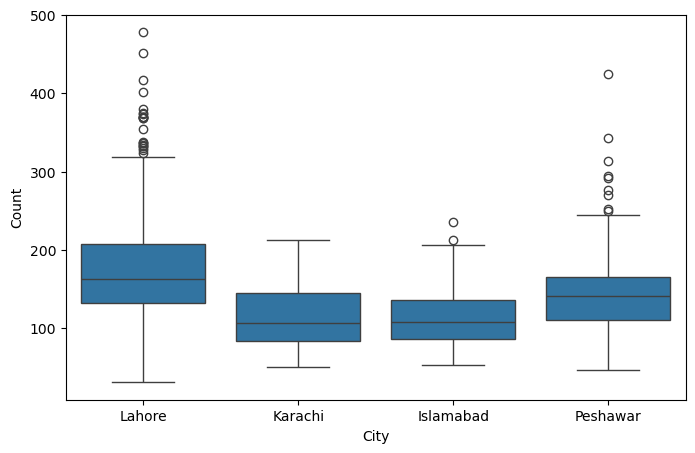

In [28]:

pm25_data["Count"] = pm25_data["Count"].replace("-", None)


pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])


pm25_data = pm25_data.dropna(subset=["Count"])


pm25_data.dtypes


sns.boxplot(x="City", y="Count", data=pm25_data)

sns.boxplot(x="City", y="Count", data=pm25_data)

plt.title("PM2.5 Pollution Levels by City")
plt.xlabel("City")
plt.ylabel("PM2.5 Value")


plt.figure(figsize=(8,5))

sns.boxplot(x="City", y="Count", data=pm25_data)



plt.savefig("../images/pollution_by_city.png")

plt.show()

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
data = pd.read_excel("../data/pakistan_aqi.xlsx")
data.head()

,Date,City,Type,Count
0,2019-05-10,Lahore,PM 2.5,231
1,2019-05-11,Lahore,PM 2.5,171
2,2019-05-12,Lahore,PM 2.5,209
3,2019-05-13,Lahore,PM 2.5,188
4,2019-05-14,Lahore,PM 2.5,194


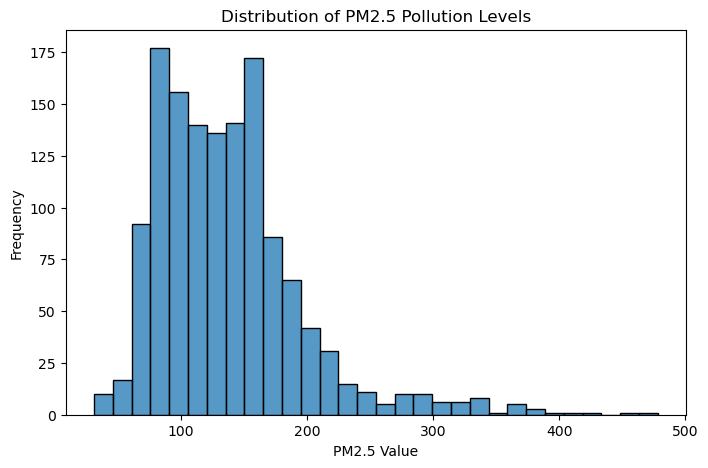

In [31]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_excel("../data/pakistan_aqi.xlsx")

# Filter PM2.5 data
pm25_data = data[data["Type"] == "PM 2.5"]

# Convert Date column to datetime
pm25_data["Date"] = pd.to_datetime(pm25_data["Date"])

# Clean Count column
pm25_data["Count"] = pm25_data["Count"].replace("-", None)
pm25_data["Count"] = pd.to_numeric(pm25_data["Count"])
pm25_data = pm25_data.dropna(subset=["Count"])

# Create histogram

plt.figure(figsize=(8,5))

sns.histplot(pm25_data["Count"], bins=30)

plt.title("Distribution of PM2.5 Pollution Levels")
plt.xlabel("PM2.5 Value")
plt.ylabel("Frequency")

plt.savefig("../images/pm25_distribution.png")

plt.show()

In [32]:
city_avg = pm25_data.groupby("City")["Count"].mean()

city_avg

City
Islamabad    113.853521
Karachi      113.655385
Lahore       178.612245
Peshawar     143.446483
Name: Count, dtype: float64

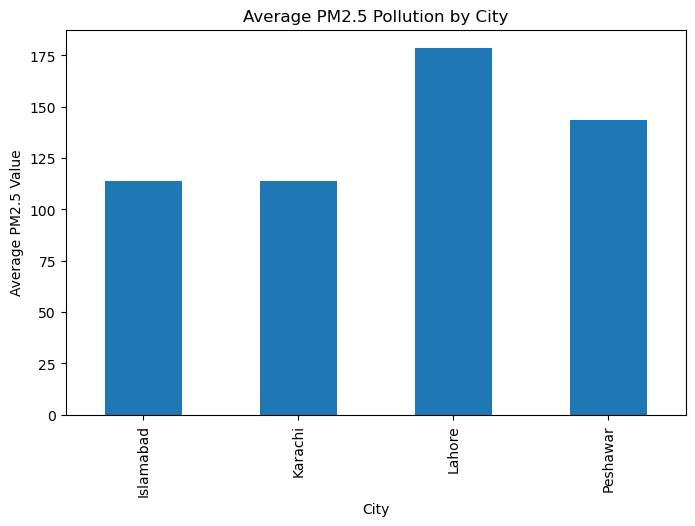

In [34]:
plt.figure(figsize=(8,5))

city_avg.plot(kind="bar")

plt.title("Average PM2.5 Pollution by City")
plt.xlabel("City")
plt.ylabel("Average PM2.5 Value")

plt.savefig("../images/avg_pollution_by_city.png")

plt.show()

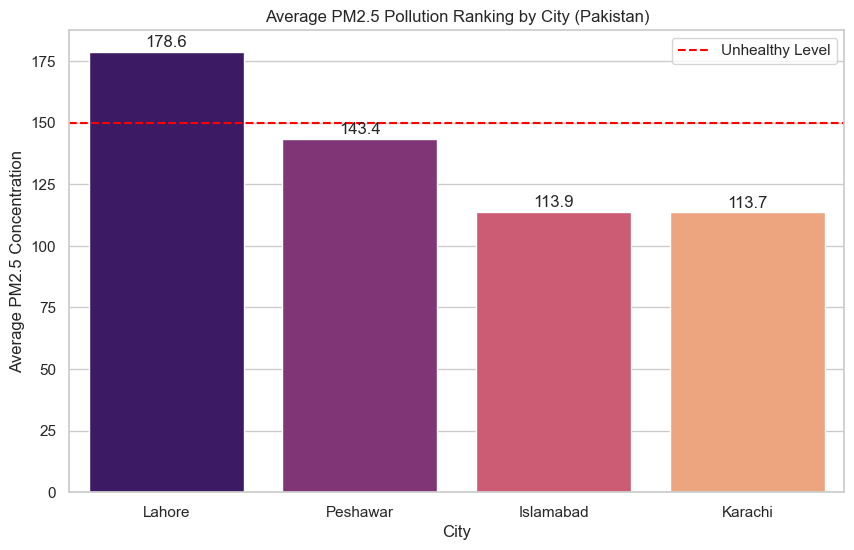

In [37]:
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
# Calculate average pollution per city
city_avg = pm25_data.groupby("City")["Count"].mean()

# Sort cities by pollution level
city_avg_sorted = city_avg.sort_values(ascending=False)

city_avg_sorted
ax = sns.barplot(
    x=city_avg_sorted.index,
    y=city_avg_sorted.values,
    hue=city_avg_sorted.index,   # assign hue
    palette="magma",
    legend=False                 # hide duplicate legend
)

# Add value labels
for i, value in enumerate(city_avg_sorted.values):
    ax.text(i, value + 2, f"{value:.1f}", ha="center")

# Reference line
plt.axhline(150, color="red", linestyle="--", label="Unhealthy Level")

plt.title("Average PM2.5 Pollution Ranking by City (Pakistan)")
plt.xlabel("City")
plt.ylabel("Average PM2.5 Concentration")

plt.legend()

plt.savefig("../images/pollution_city_ranking_advanced.png")

plt.show()
